# MAST Direct-Classification Pipeline — Prefix Window Ablation (0 / 3 / All)

Implements `mast_window_ablation_plan.md`. Model: **Qwen3-8B** (plain `transformers`, optional 4-bit via bitsandbytes).

Pipeline: **Summarizer** (per step) → **Stage 1** (per step, classify against the 14 MAST modes) → **Stage 2** (per trajectory, pick the decisive step). The only variable is how many prior step summaries Stage 1 sees: `0`, `3`, or `all`.

**Sequencing rule (hard requirement from the plan):** run one phase, read its report, and only then run the next. The notebook is laid out so each phase is its own section. Phases 3 and 4 refuse to start unless the previous window's report file exists.

```
Setup + shared code   (run once, and again after any kernel restart)
Phase 2  window = 0   -> results_window0.jsonl, window0_report.md   -> STOP, read it
Phase 3  window = 3   -> results_window3.jsonl, window3_report.md   -> STOP, read it (+ vs window 0)
Phase 4  window = all -> results_windowAll.jsonl, windowAll_report.md
Combined comparison   (only after all three)
```

All calls are resumable: results are appended to jsonl as they finish, and a re-run skips work already on disk.

## Setup

In [ ]:
# Apple Silicon: mlx-lm runs 4-bit Qwen3-8B natively. (bitsandbytes is CUDA-only and is not needed on a Mac.)
%pip install -q -U "transformers>=4.51" mlx-lm pandas matplotlib tabulate tqdm huggingface_hub torch
# On a CUDA box also: %pip install -q -U accelerate bitsandbytes

In [74]:
import json, re, time, shutil, gc
from pathlib import Path
from collections import Counter

import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ---------------- Config ----------------
PROJECT_DIR = Path.cwd()                      # open this notebook from the Experiment4 folder
OUT_DIR = PROJECT_DIR
PROMPT_DIR = OUT_DIR / "prompts"
PROMPT_DIR.mkdir(exist_ok=True)

BACKEND = "auto"           # "auto" | "mlx" | "cuda"   auto = cuda if available, else mlx (Apple Silicon)
MLX_MODEL_ID = "mlx-community/Qwen3-8B-4bit"   # 4-bit quantized; use "mlx-community/Qwen3-8B-8bit" for higher fidelity (~9 GB)
CUDA_MODEL_ID = "Qwen/Qwen3-8B"
USE_4BIT = "auto"          # CUDA only. auto = 4-bit unless the GPU has >= 24 GB
MAX_STEP_CHARS = 8000      # a single step's raw text is truncated (middle cut) beyond this, to bound context
MAX_STAGE2_STEP_CHARS = 1500   # per-candidate full-text cap shown to Stage 2 (a trajectory can have 15+
                                # candidates, so this is tighter than MAX_STEP_CHARS to bound Stage 2's context)
MAX_NEW_TOKENS = {"summarizer": 120, "stage1": 300, "stage2": 200}

# Held-out set. The plan mentions 56 trajectories / 1,356 steps; the file in Experiment2 is what the
# taxonomy experiments used. Point this at whichever file you want.
HELD_OUT_CANDIDATES = [PROJECT_DIR / "held_out_test_set.json",
                       PROJECT_DIR.parent / "Experiment3"/"whodunit_experiment3"/ "held_out_test_set.json"]
HELD_OUT_PATH = next((p for p in HELD_OUT_CANDIDATES if p.exists()), None)
assert HELD_OUT_PATH is not None, f"held_out_test_set.json not found in {HELD_OUT_CANDIDATES}"

# Quick smoke test: set to an int to only run the first N trajectories (results go to *_smoke files).
LIMIT_TRAJECTORIES = None

SUFFIX = "_smoke" if LIMIT_TRAJECTORIES else ""
SUMMARY_CACHE_PATH = OUT_DIR / f"summaries{SUFFIX}.jsonl"
WINDOW_TAGS = {0: "window0", 3: "window3", "all": "windowAll"}
def results_path(w): return OUT_DIR / f"results_{WINDOW_TAGS[w]}{SUFFIX}.jsonl"
def report_path(w):  return OUT_DIR / f"{WINDOW_TAGS[w]}_report{SUFFIX}.md"

HISTORY_MODES = {"1.3", "1.4", "2.1", "2.5", "2.6"}   # modes that structurally need prior context
print("held-out file:", HELD_OUT_PATH, "| device:", "cuda" if torch.cuda.is_available() else "cpu/mps")
if BACKEND == "auto": BACKEND = "cuda" if torch.cuda.is_available() else "mlx"
MODEL_ID = MLX_MODEL_ID if BACKEND == "mlx" else CUDA_MODEL_ID
print("backend:", BACKEND, "| model:", MODEL_ID)

held-out file: /Users/user/Desktop/thesis/error_localization/Experiment3/whodunit_experiment3/held_out_test_set.json | device: cpu/mps
backend: mlx | model: mlx-community/Qwen3-8B-4bit


### Prompts (versioned files — written once, then byte-identical across every window)

The three prompt files are created in `prompts/` only if they don't already exist. **Before running at scale**, check the mode wording against the MAST paper appendix (arXiv:2503.13657) and edit `prompts/modes.md` — the plan flags the current text as a working paraphrase. If you edit prompts after running a window, delete that window's results, or the comparison is invalid.

In [ ]:
MODES_MD = '''SPECIFICATION
1.1 Disobey Task Specification — the action violates an explicit constraint
    or requirement stated in the task instructions.
1.2 Disobey Role Specification — the agent acts outside its assigned role
    or capabilities.
1.3 Step Repetition — the agent redundantly repeats an action already
    completed, with no new justification.
1.4 Loss of Conversation History — the agent acts as if information
    established earlier in the trajectory no longer exists or applies.
1.5 Unaware of Termination Conditions — the agent continues acting after
    the task's completion criteria have already been met.

INTER-AGENT MISALIGNMENT
2.1 Conversation Reset — the interaction restarts from scratch, discarding
    prior progress or context without cause.
2.2 Fail to Ask for Clarification — the agent proceeds under real ambiguity
    it should have raised, instead of guessing.
2.3 Task Derailment — the step drifts away from the task's actual goal.
2.4 Information Withholding — the agent has information relevant to
    another agent's task and fails to share it.
2.5 Ignored Other Agent's Input — the agent disregards or overrides a
    relevant instruction, correction, or finding another agent gave it.
2.6 Reasoning-Action Mismatch — the agent's own stated reasoning does not
    match the action it actually takes.

TASK VERIFICATION
3.1 Premature Termination — the task ends before the goal is achieved or
    fully verified.
3.2 No or Incomplete Verification — a result is not checked, or the check
    is superficial.
3.3 Incorrect Verification — a verification step reaches the wrong
    conclusion.
'''

SUMMARIZER_MD = '''You are writing a one-line, purely factual summary of a single step in a
multi-agent trajectory, for use as context in a later review.

RULES:
- State only what the agent did — the concrete action, not its outcome,
  quality, or correctness.
- Do NOT evaluate, judge, or flag anything as wrong, suspicious, correct,
  or notable. Language like "failed to," "incorrectly," "without
  verifying" is evaluative — do not use it even if it seems accurate.
- Do not add information not in the step text.
- One line, one sentence, plain and specific (name the actual tool, value,
  or target mentioned).

OUTPUT FORMAT (strict, no other text):
SUMMARY: <one factual sentence>
=====USER=====
STEP:
agent: {agent_name}
"""
{step_text}
"""
'''

STAGE1_MD = '''You are checking ONE specific step in a multi-agent system's trajectory for
evidence of any of 14 known failure modes.

DEFAULT TO NONE. Most steps are normal. Only report a mode if the step
gives clear, direct evidence — not a plausible inference, not speculation.
You must be able to quote the exact text that shows it.

Judge only the CURRENT STEP. Use the prefix only as context for modes that
require history (repetition, lost context, ignored input, reset) — do not
flag a prior step's problem as if it belongs to the current step.

FRAMEWORK-NOISE CHECK: Some text in a step is scaffolding inserted by the
multi-agent framework itself, not a statement or decision made by the
agent. Do not treat it as evidence of anything:
- Routing lines like "Next speaker X" are the framework choosing who acts
  next. They are not a statement by any agent and never count as evidence
  of a conversation reset (2.1) or anything else — the agent didn't say
  this, the framework did.
- An orchestrating/delegating agent restating or re-issuing the CURRENT,
  still-unfinished instruction to a worker agent (even in near-identical
  wording across consecutive turns) is normal delegation scaffolding, not
  Step Repetition (1.3) — 1.3 requires an action that was already
  completed being redundantly done again, not an unfinished instruction
  being repeated. Before flagging 1.3, confirm the earlier occurrence
  describes a completed action, not an open request.

AGENCY CHECK: If the acting agent is a pure execution/tool component (e.g.
Computer_terminal) and its step is only reporting the mechanical result of
code it ran (an exit code, a traceback, "no code to execute"), it has no
independent judgment, planning, or communication role. Do not apply modes
that require agency or decision-making (1.2, 2.2, 2.4, 2.5, 2.6, 3.2, 3.3)
to such a step based on the execution result alone. At most, 1.1 or 3.1 may
apply if the step itself directly and independently caused the task to end
incorrectly — not merely because the code it ran was wrong.

A step may show more than one mode. List every mode with clear evidence,
or NONE.

Before answering, think step by step:
1. Strip out anything covered by the FRAMEWORK-NOISE CHECK — routing lines,
   and (for 1.3 candidates specifically) confirm the repeated thing is a
   completed action, not a restated open instruction.
2. What is this step's agent actually doing — acting, reporting, deciding,
   or communicating?
3. Does the AGENCY CHECK rule out any modes outright for this step?
4. For each remaining mode, is there a literal quote in THIS step (not the
   prefix, not framework scaffolding) that satisfies it? If you have to
   infer or assume, it doesn't count — move on.
5. Only after checking every mode this way, decide the final verdict.

Keep this reasoning brief (2-4 sentences). Do not use it to justify
borderline calls — if step 4 didn't turn up a literal quote from the
agent's own actual content, the answer is NONE regardless of what the
reasoning suggests.

FAILURE MODES:
{modes}

OUTPUT FORMAT (strict — REASONING first, then the final block with no
other text after it):
REASONING: <brief step-by-step check above>
MODE: <comma-separated codes> or NONE
EVIDENCE: <exact quote supporting each mode listed, omit if NONE>
=====USER=====
TASK: {task_description}

RECENT STEPS (context only — judge only the CURRENT STEP below):
{windowed_prefix}

CURRENT STEP TO JUDGE:
step {step_id} | agent: {agent_name}
"""
{step_text}
"""
'''
'''

STAGE2_MD = '''You are given a multi-agent trajectory that failed, and every step Stage 1
flagged as showing evidence of a failure mode, WITH THE FULL TEXT OF EACH FLAGGED STEP.
Candidates are grouped by agent (in order of first appearance), and numbered within
their group — e.g. [W1], [W2] are WebSurfer's 1st and 2nd flagged steps, in chronological
order within that group. Your job is to decide which ONE candidate, across all agents, is
the single decisive, root-cause step. Read each candidate's actual text yourself and judge
it directly — Stage 1's mode label is given for reference only, not a verdict.

WORK IN TWO PASSES.

PASS 1 — within each agent's own group, if it has more than one candidate, decide: are
these independent failures, or is this one agent repeating/continuing the same underlying
problem across several steps (a loop, a repeated bad query, the same unverified claim
carried forward)? If it's the latter, the decisive one is normally the EARLIEST step in
that group where the problem was actually introduced — not necessarily the first flagged
step overall, because early candidates in a group are often legitimate exploration that
Stage 1 over-flagged, and the real problem starts partway through. Read the full text: does
the earliest candidate actually contain a mistake, or is it a reasonable action that later
candidates in the same group repeat without correcting? Pick the true within-group origin
point, not just [X1].

PASS 2 — you now have at most one candidate per agent. Compare across agents using the
rules below.

EXAMPLE (illustrative, not from a real graded case):
WebSurfer group: [W1] step 4 — searches "Ted Danson TV series list", gets a results page.
[W2] step 11 — clicks into a "Credits" page, reasonable navigation. [W3] step 15 — scrolls
and OCRs a results page but does not record the season counts the task asked for. [W4]
step 19 — scrolls again, still not recording season counts, now also mis-states one
series' rating. [W5] step 23 — scrolls a third time, same gap.
Correct within-group reasoning: [W1] and [W2] are normal search/navigation, not failures —
searching and clicking into a page are not mistakes on their own. The actual problem
starts at [W3] (step 15): that's where the agent had the page in front of it and failed to
extract the information the task required, and [W4]/[W5] are the SAME unfixed gap
repeating, not new failures. So this group's decisive candidate is step 15, not step 4 —
even though step 4 is both the earliest flagged step overall and the earliest in this
group. Do not pick step 4 just because it came first; pick step 15 because that's where
the actual mistake was introduced.

RULES:
1. Do not default to the earliest candidate automatically — in either pass. Read what the
   candidate actually says before crediting or discounting it.
2. Do not default to blaming a delegating agent merely because it assigned
   work to the agent that erred — only if its OWN decision was itself
   wrong.
3. Use a counterfactual test: if this step had been done correctly, would
   the outcome plausibly have changed? Among candidates that pass, pick
   the earliest TRUE origin point (per PASS 1), not the earliest flagged step.
4. If genuinely unsure, say so.
5. A step that is purely a tool/terminal's mechanical execution output (a
   stack trace, exit code, "no code to execute") cannot be the decisive step
   if an earlier candidate in the same trajectory represents an actual
   authored decision or action — the terminal only reports what it was
   given, it does not decide anything. Check this against the candidate's
   own full text, not against how Stage 1 described it.
6. If a candidate's full text does not actually support the mode Stage 1
   assigned it, discount it accordingly — Stage 1 can be wrong.

OUTPUT FORMAT (strict, no other text):
DECISIVE_STEP: <step number, or UNSURE>
DECISIVE_AGENT: <agent name, or UNSURE>
JUSTIFICATION: <one sentence, naming which pass (within-group or cross-agent) decided it>
=====USER=====
TASK: {task_description}

CANDIDATE STEPS (grouped by agent, full text):
{candidates}
'''
for name, text in [("modes.md", MODES_MD), ("summarizer.md", SUMMARIZER_MD),
                   ("stage1.md", STAGE1_MD), ("stage2.md", STAGE2_MD)]:
    p = PROMPT_DIR / name
    if p.exists():
        print(f"  keeping existing prompts/{name}")
    else:
        p.write_text(text); print(f"  wrote prompts/{name}")

def load_prompt(name):
    system, user = (PROMPT_DIR / name).read_text().split("=====USER=====\n", 1)
    return system.rstrip("\n"), user.rstrip("\n")

MODES_TEXT = (PROMPT_DIR / "modes.md").read_text().rstrip("\n")
VALID_MODES = set(re.findall(r"^(\d\.\d)\s", MODES_TEXT, flags=re.M))
assert len(VALID_MODES) == 14, VALID_MODES

SUMMARIZER_SYS, SUMMARIZER_USER = load_prompt("summarizer.md")
STAGE1_SYS, STAGE1_USER = load_prompt("stage1.md")
STAGE1_SYS = STAGE1_SYS.replace("{modes}", MODES_TEXT)
STAGE2_SYS, STAGE2_USER = load_prompt("stage2.md")

def fill(template: str, **kw) -> str:
    """Single-pass substitution so text inside a value (e.g. a step containing '{agent_name}') is never re-expanded."""
    return re.sub(r"\{(\w+)\}", lambda m: str(kw[m.group(1)]) if m.group(1) in kw else m.group(0), template)

  keeping existing prompts/modes.md
  keeping existing prompts/summarizer.md
  keeping existing prompts/stage1.md
  keeping existing prompts/stage2.md


### Data loading

`step_id` is the index into the trajectory's `history` list (the same indexing as ground-truth `mistake_step`). The human turn (the task) is not a step. The agent name is the base role, so `Orchestrator (thought)` and `Orchestrator (-> WebSurfer)` both become `Orchestrator`.

In [76]:
def base_role(raw: str) -> str:
    return re.split(r"\s*\(", (raw or "").strip(), maxsplit=1)[0].strip()

def clip(text: str, n: int = MAX_STEP_CHARS) -> str:
    if len(text) <= n: return text
    h = n // 2
    return text[:h] + f"\n[... {len(text) - n} chars truncated ...]\n" + text[-h:]

def load_trajectory(raw: dict) -> dict:
    steps, task = [], raw.get("question", "")
    for i, item in enumerate(raw.get("history", [])):
        agent = base_role(item.get("name") or item.get("role", ""))
        content = item.get("content", "")
        content = content if isinstance(content, str) else json.dumps(content, ensure_ascii=False)
        if agent.lower() == "human":
            if not task: task = content.strip()
            continue
        if not agent: continue
        steps.append({"step_id": i, "agent": agent, "text": clip(content)})
    try: gt_step = int(raw.get("mistake_step"))
    except (TypeError, ValueError): gt_step = None
    return {"trajectory_id": raw["question_ID"], "task": task.strip(), "steps": steps,
            "gt_agent": base_role(raw.get("mistake_agent", "")), "gt_step": gt_step}

raw = json.loads(HELD_OUT_PATH.read_text())
trajectories = [load_trajectory(r) for r in raw]
if LIMIT_TRAJECTORIES: trajectories = trajectories[:LIMIT_TRAJECTORIES]
n_steps = sum(len(t["steps"]) for t in trajectories)
gt_in_steps = sum(any(s["step_id"] == t["gt_step"] for s in t["steps"]) for t in trajectories)
print(f"{len(trajectories)} trajectories, {n_steps} steps; ground-truth mistake step found among steps for {gt_in_steps}/{len(trajectories)}")
if len(trajectories) != 56: print("  note: the plan mentions 56 trajectories / 1,356 steps; this file differs — check HELD_OUT_PATH if that matters.")

# Full raw step text, for Stage 2 (which now sees each candidate's complete text, not just
# Stage 1's evidence quote).
STEPS_BY_ID = {(t["trajectory_id"], s["step_id"]): s for t in trajectories for s in t["steps"]}

56 trajectories, 1356 steps; ground-truth mistake step found among steps for 56/56


### Load Qwen3-8B

Thinking mode is switched off (`enable_thinking=False`) so outputs follow the strict formats. **Mac / Apple Silicon:** uses MLX with `mlx-community/Qwen3-8B-4bit` (4-bit, ~5 GB; needs roughly 16 GB unified memory to be comfortable). **CUDA:** plain `transformers`, with NF4 4-bit automatically on GPUs under 24 GB.

In [77]:
use_4bit = True if BACKEND == "mlx" else None   # recorded in reports
t0 = time.time()
if BACKEND == "mlx":
    from mlx_lm import load as mlx_load, generate as mlx_generate
    from mlx_lm.sample_utils import make_sampler
    model, tok = mlx_load(MLX_MODEL_ID)
else:
    from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
    def want_4bit():
        if USE_4BIT != "auto": return bool(USE_4BIT)
        return torch.cuda.get_device_properties(0).total_memory / 2**30 < 24
    use_4bit = want_4bit()
    kwargs = {}
    if use_4bit:
        kwargs["quantization_config"] = BitsAndBytesConfig(
            load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_use_double_quant=True,
            bnb_4bit_compute_dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16)
    else:
        kwargs["torch_dtype"] = "auto"
    tok = AutoTokenizer.from_pretrained(CUDA_MODEL_ID)
    model = AutoModelForCausalLM.from_pretrained(CUDA_MODEL_ID, device_map="auto", **kwargs).eval()
print(f"loaded {MODEL_ID} (backend={BACKEND}, 4bit={use_4bit}) in {time.time() - t0:.0f}s")

Fetching 9 files: 100%|██████████| 9/9 [00:00<00:00, 996.46it/s]


loaded mlx-community/Qwen3-8B-4bit (backend=mlx, 4bit=True) in 3s


### Model call wrapper with strict-format enforcement

Each call is parsed against its strict format. On malformed output it is **retried once** (sampled at T=0.3, since greedy would just repeat itself). Two failures → the record is logged as `parse_error` — never silently coerced into NONE. Token counts and latency are recorded per call for the cost analysis.

In [78]:
def generate(system: str, user: str, max_new_tokens: int, sample: bool = False):
    msgs = [{"role": "system", "content": system}, {"role": "user", "content": user}]
    text = tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True, enable_thinking=False)
    t0 = time.time()
    if BACKEND == "mlx":
        ids = tok.encode(text)
        sampler = make_sampler(temp=0.3, top_p=0.9) if sample else make_sampler(temp=0.0)
        out_text = mlx_generate(model, tok, prompt=ids, max_tokens=max_new_tokens, sampler=sampler, verbose=False)
        return {"text": out_text.strip(), "in_tok": len(ids), "out_tok": len(tok.encode(out_text)),
                "latency": time.time() - t0}
    inputs = tok(text, return_tensors="pt").to(model.device)
    gen_kw = dict(do_sample=True, temperature=0.3, top_p=0.9) if sample else dict(do_sample=False)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, pad_token_id=tok.eos_token_id, **gen_kw)
    new = out[0, inputs["input_ids"].shape[1]:]
    return {"text": tok.decode(new, skip_special_tokens=True).strip(),
            "in_tok": int(inputs["input_ids"].shape[1]), "out_tok": int(new.shape[0]),
            "latency": time.time() - t0}

def call_with_retry(system, user, max_new_tokens, parser):
    """Returns (parsed_or_None, usage). usage sums tokens/latency over both attempts."""
    usage = {"in_tok": 0, "out_tok": 0, "latency": 0.0, "attempts": 0}
    raw_text = ""
    for attempt in range(2):
        g = generate(system, user, max_new_tokens, sample=(attempt == 1))
        for k in ("in_tok", "out_tok", "latency"): usage[k] += g[k]
        usage["attempts"] += 1
        raw_text = g["text"]
        parsed = parser(raw_text)
        if parsed is not None:
            return parsed, usage, raw_text
    return None, usage, raw_text

# ---------------- parsers (return None if the format is violated) ----------------
def parse_summary(t):
    m = re.search(r"^SUMMARY:\s*(.+)$", t, flags=re.M)
    return {"summary": " ".join(m.group(1).split())} if m and m.group(1).strip() else None

def parse_stage1(t):
    m = re.search(r"^MODE:\s*(.+)$", t, flags=re.M)
    if not m: return None
    val = m.group(1).strip().strip("*` ")
    if val.upper().startswith("NONE"):
        return {"modes": [], "evidence": ""}
    codes = [c.strip() for c in re.split(r"[,\s]+", val) if c.strip()]
    if not codes or any(c not in VALID_MODES for c in codes): return None
    ev = re.search(r"^EVIDENCE:\s*(.+)", t, flags=re.M | re.S)
    evidence = " ".join(ev.group(1).split()) if ev else ""
    if not evidence: return None          # a mode without a quote violates the format
    return {"modes": sorted(set(codes)), "evidence": evidence}

def parse_stage2(t):
    s = re.search(r"^DECISIVE_STEP:\s*(.+)$", t, flags=re.M)
    a = re.search(r"^DECISIVE_AGENT:\s*(.+)$", t, flags=re.M)
    j = re.search(r"^JUSTIFICATION:\s*(.+)", t, flags=re.M | re.S)
    if not (s and a and j): return None
    sv = s.group(1).strip().strip("*` ")
    if sv.upper().startswith("UNSURE"): step = None
    else:
        n = re.match(r"\d+", sv)
        if not n: return None
        step = int(n.group(0))
    av = a.group(1).strip().strip("*` ")
    agent = None if av.upper().startswith("UNSURE") else base_role(av)
    return {"predicted_step": step, "predicted_agent": agent, "justification": " ".join(j.group(1).split())}

# ---------------- quick format check on the plan's worked example ----------------
_ex = call_with_retry(SUMMARIZER_SYS,
    fill(SUMMARIZER_USER, agent_name="WebSurfer",
         step_text="WebSurfer searched 'Q3 revenue figures' and opened the first result, a Q2 report cached from an earlier session."),
    MAX_NEW_TOKENS["summarizer"], parse_summary)
print("worked-example summary ->", _ex[0], "|", _ex[1])

worked-example summary -> {'summary': "WebSurfer searched for 'Q3 revenue figures' and opened the first result, which was a Q2 report cached from an earlier session."} | {'in_tok': 210, 'out_tok': 32, 'latency': 30.846771955490112, 'attempts': 1}


### Pipeline functions

In [79]:
def read_jsonl(p):
    return [json.loads(l) for l in open(p) if l.strip()] if Path(p).exists() else []

def append_jsonl(p, rec):
    with open(p, "a") as f: f.write(json.dumps(rec, ensure_ascii=False) + "\n")

# ---------- Summarizer: window-independent (built from raw step text only), so cached once and shared ----------
def get_summaries():
    """Returns {(trajectory_id, step_id): record}. Computes any that are missing, appending to the cache."""
    cache = {(r["trajectory_id"], r["step_id"]): r for r in read_jsonl(SUMMARY_CACHE_PATH)}
    todo = [(t, s) for t in trajectories for s in t["steps"] if (t["trajectory_id"], s["step_id"]) not in cache]
    for t, s in tqdm(todo, desc="summarizer"):
        parsed, usage, raw_text = call_with_retry(
            SUMMARIZER_SYS, fill(SUMMARIZER_USER, agent_name=s["agent"], step_text=s["text"]),
            MAX_NEW_TOKENS["summarizer"], parse_summary)
        rec = {"trajectory_id": t["trajectory_id"], "step_id": s["step_id"], "agent": s["agent"],
               "summary": parsed["summary"] if parsed else None, "parse_error": parsed is None,
               "raw": raw_text if parsed is None else None, **usage}
        append_jsonl(SUMMARY_CACHE_PATH, rec)
        cache[(rec["trajectory_id"], rec["step_id"])] = rec
    return cache

def build_prefix(step_log, window):
    entries = step_log if window == "all" else (step_log[-window:] if window else [])
    return "\n".join(f"step {e['step_id']} | {e['agent']}: {e['summary']}" for e in entries)

def format_candidates(cands):
    """Stage 2 sees each flagged candidate's full step text (clipped to MAX_STAGE2_STEP_CHARS), not just
    Stage 1's evidence quote -- so it can judge the actual text itself rather than trust Stage 1's excerpt."""
    blocks = []
    for c in cands:
        step = STEPS_BY_ID.get((c["trajectory_id"], c["step_id"]))
        text = clip(step["text"], MAX_STAGE2_STEP_CHARS) if step else "<step text unavailable>"
        blocks.append(
            f'- step {c["step_id"]} | agent: {c["agent"]} | stage1 mode(s): {", ".join(c["modes"])}\n'
            f'  FULL STEP TEXT:\n  """\n  {text}\n  """'
        )
    return "\n".join(blocks)

def run_window(window):
    assert window in (0, 3, "all")
    path = results_path(window)
    summaries = get_summaries()
    done = read_jsonl(path)
    s1_done = {(r["trajectory_id"], r["step_id"]) for r in done if r["kind"] == "stage1"}
    s2_done = {r["trajectory_id"] for r in done if r["kind"] == "stage2"}

    for t in tqdm(trajectories, desc=f"window={window}"):
        tid = t["trajectory_id"]
        step_log = []
        for s in t["steps"]:
            key = (tid, s["step_id"])
            if key not in s1_done:
                prefix = build_prefix(step_log, window)
                parsed, usage, raw_text = call_with_retry(
                    STAGE1_SYS,
                    fill(STAGE1_USER, task_description=t["task"], windowed_prefix=prefix,
                         step_id=s["step_id"], agent_name=s["agent"], step_text=s["text"]),
                    MAX_NEW_TOKENS["stage1"], parse_stage1)
                rec = {"kind": "stage1", "window": window, "trajectory_id": tid, "step_id": s["step_id"],
                       "agent": s["agent"], "modes": parsed["modes"] if parsed else [],
                       "evidence": parsed["evidence"] if parsed else "", "parse_error": parsed is None,
                       "raw": raw_text if parsed is None else None, **usage}
                append_jsonl(path, rec); done.append(rec); s1_done.add(key)
            # Summarizer runs after the step is processed and appends to step_log (append-only, raw-text-only)
            sm = summaries[key]
            step_log.append({"step_id": s["step_id"], "agent": s["agent"],
                             "summary": sm["summary"] or "(summary unavailable)"})

        if tid not in s2_done:
            cands = sorted([r for r in done if r["kind"] == "stage1" and r["trajectory_id"] == tid and r["modes"]],
                           key=lambda r: r["step_id"])
            if cands:
                parsed, usage, raw_text = call_with_retry(
                    STAGE2_SYS, fill(STAGE2_USER, task_description=t["task"], candidates=format_candidates(cands)),
                    MAX_NEW_TOKENS["stage2"], parse_stage2)
                rec = {"kind": "stage2", "window": window, "trajectory_id": tid,
                       "predicted_step": parsed["predicted_step"] if parsed else None,
                       "predicted_agent": parsed["predicted_agent"] if parsed else None,
                       "justification": parsed["justification"] if parsed else "",
                       "num_candidates": len(cands), "parse_error": parsed is None,
                       "raw": raw_text if parsed is None else None, **usage}
            else:
                rec = {"kind": "stage2", "window": window, "trajectory_id": tid, "predicted_step": None,
                       "predicted_agent": None, "justification": "", "num_candidates": 0,
                       "parse_error": False, "raw": None, "in_tok": 0, "out_tok": 0, "latency": 0.0, "attempts": 0}
            append_jsonl(path, rec); done.append(rec); s2_done.add(tid)
    return done

### Stage 2 prompt change — one-time migration for existing results

Stage 2 now sees each candidate's full step text (clipped to `MAX_STAGE2_STEP_CHARS`), not just
Stage 1's evidence quote — see `prompts/stage2.md`. This changes the Stage 2 prompt, so any
`stage2` records already on disk (from before this change) were produced by the old prompt and
are stale; Stage 1 records are unaffected (Stage 1's prompt didn't change) and stay cached.

Run the cell below **once** to strip stale `stage2` records from each window's results file. The
next `run_window(...)` call then reuses the cached Stage 1 flags and recomputes only Stage 2, with
the new full-text prompt. Safe to run even if there's nothing to strip (no-op then).

In [80]:
def migrate_drop_stage2(window):
    """Removes cached stage2 records for `window` so the next run_window() recomputes them with the
    current Stage 2 prompt, while keeping the (unaffected) cached stage1 records."""
    p = results_path(window)
    recs = read_jsonl(p)
    kept = [r for r in recs if r["kind"] != "stage2"]
    dropped = len(recs) - len(kept)
    if dropped:
        with open(p, "w") as f:
            for r in kept: f.write(json.dumps(r, ensure_ascii=False) + "\n")
    print(f"{WINDOW_TAGS[window]}: dropped {dropped} stale stage2 record(s), kept {len(kept)} stage1 record(s)")

for _w in (0, 3, "all"):
    if results_path(_w).exists():
        migrate_drop_stage2(_w)

window0: dropped 0 stale stage2 record(s), kept 1334 stage1 record(s)
window3: dropped 0 stale stage2 record(s), kept 1334 stage1 record(s)
windowAll: dropped 0 stale stage2 record(s), kept 822 stage1 record(s)


### Metrics, plots, and report (identical for every window)

Includes the skepticism checks the plan makes routine: naive-baseline comparison, agent-correct/step-wrong breakdown, prediction-collapse check, zero-candidate rate, and `parse_error` rate.

Conventions: **recall** = fraction of trajectories whose ground-truth mistake step got ≥1 mode from Stage 1 (a `parse_error` on that step counts as *not* flagged, and the parse-error rate is reported alongside). Stage 2 predictions of `None` (UNSURE / zero candidates / parse error) count as wrong for accuracy. Cost includes the (shared, cached) Summarizer calls, since they are part of the pipeline's per-window cost.

In [81]:
ALL_MODES = sorted(VALID_MODES)
GT = {t["trajectory_id"]: (t["gt_agent"], t["gt_step"]) for t in trajectories}

def naive_baselines():
    agents = Counter(a for a, _ in GT.values()); steps = Counter(s for _, s in GT.values()); joint = Counter(GT.values())
    n = len(GT)
    return {"agent": agents.most_common(1)[0][1] / n, "agent_label": agents.most_common(1)[0][0],
            "step": steps.most_common(1)[0][1] / n, "step_label": steps.most_common(1)[0][0],
            "joint": joint.most_common(1)[0][1] / n, "joint_label": joint.most_common(1)[0][0]}

def compute_metrics(window):
    recs = read_jsonl(results_path(window))
    s1 = [r for r in recs if r["kind"] == "stage1"]; s2 = {r["trajectory_id"]: r for r in recs if r["kind"] == "stage2"}
    summaries = get_summaries()
    n_traj = len(trajectories)
    m = {"window": window, "n_traj": n_traj, "n_steps": len(s1)}

    m["parse_error_rate_stage1"] = sum(r["parse_error"] for r in s1) / max(1, len(s1))
    m["parse_error_rate_stage2"] = sum(r["parse_error"] for r in s2.values()) / max(1, sum(r["num_candidates"] > 0 for r in s2.values()))
    m["parse_error_rate_summarizer"] = sum(r["parse_error"] for r in summaries.values()) / max(1, len(summaries))
    m["step_flag_rate"] = sum(bool(r["modes"]) for r in s1) / max(1, len(s1))

    # mode-level flag rate = fraction of steps in which each mode fired
    mode_counts = Counter(c for r in s1 for c in r["modes"])
    m["mode_flag_rate"] = {c: mode_counts.get(c, 0) / max(1, len(s1)) for c in ALL_MODES}
    m["mode_counts"] = {c: mode_counts.get(c, 0) for c in ALL_MODES}

    # recall of true mistake steps
    by_step = {(r["trajectory_id"], r["step_id"]): r for r in s1}
    gt_recs = [(tid, by_step.get((tid, st))) for tid, (_, st) in GT.items() if st is not None]
    gt_recs = [(tid, r) for tid, r in gt_recs if r is not None]
    m["n_gt_steps_evaluable"] = len(gt_recs)
    flagged = [r for _, r in gt_recs if r["modes"]]
    m["recall"] = len(flagged) / max(1, len(gt_recs))
    m["recall_history_modes"] = sum(any(c in HISTORY_MODES for c in r["modes"]) for _, r in gt_recs) / max(1, len(gt_recs))
    m["recall_context_indep_modes"] = sum(any(c not in HISTORY_MODES for c in r["modes"]) for _, r in gt_recs) / max(1, len(gt_recs))
    m["gt_step_parse_errors"] = sum(r["parse_error"] for _, r in gt_recs)

    # stage 2 accuracy
    ag_ok = st_ok = jt_ok = ag_ok_st_bad = 0
    for tid, (ga, gs) in GT.items():
        r = s2.get(tid)
        pa, ps = (r["predicted_agent"], r["predicted_step"]) if r else (None, None)
        a, s = (pa == ga), (ps is not None and ps == gs)
        ag_ok += a; st_ok += s; jt_ok += a and s; ag_ok_st_bad += a and not s
    m.update({"agent_acc": ag_ok / n_traj, "step_acc": st_ok / n_traj, "joint_acc": jt_ok / n_traj,
              "agent_correct_step_wrong": ag_ok_st_bad,
              "agent_correct_step_wrong_share": ag_ok_st_bad / max(1, ag_ok)})
    m["baseline"] = naive_baselines()

    m["pred_agent_dist"] = dict(Counter((r["predicted_agent"] or "None/UNSURE") for r in s2.values() if r["num_candidates"] > 0))
    m["gt_agent_dist"] = dict(Counter(a for a, _ in GT.values()))
    m["zero_candidate_rate"] = sum(r["num_candidates"] == 0 for r in s2.values()) / n_traj
    m["cands_per_traj"] = [r["num_candidates"] for r in s2.values()]
    m["unsure_rate"] = sum(r["num_candidates"] > 0 and r["predicted_step"] is None for r in s2.values()) / max(1, sum(r["num_candidates"] > 0 for r in s2.values()))

    # cost (Summarizer + Stage 1 + Stage 2)
    tok_s1 = sum(r["in_tok"] + r["out_tok"] for r in s1); tok_s2 = sum(r["in_tok"] + r["out_tok"] for r in s2.values())
    tok_sm = sum(r["in_tok"] + r["out_tok"] for r in summaries.values())
    lat = sum(r["latency"] for r in s1) + sum(r["latency"] for r in s2.values()) + sum(r["latency"] for r in summaries.values())
    m.update({"tokens_summarizer": tok_sm, "tokens_stage1": tok_s1, "tokens_stage2": tok_s2,
              "tokens_total": tok_sm + tok_s1 + tok_s2, "tokens_per_traj": (tok_sm + tok_s1 + tok_s2) / n_traj,
              "stage1_in_tokens_per_step": sum(r["in_tok"] for r in s1) / max(1, len(s1)),
              "latency_total_s": lat, "latency_per_traj_s": lat / n_traj})
    return m

def plot_window(m, save=True):
    w = m["window"]; label = f"window={w}"
    fig, ax = plt.subplots(2, 2, figsize=(14, 9)); fig.suptitle(f"MAST pipeline — {label}", fontsize=14)
    a = ax[0, 0]
    a.bar(ALL_MODES, [m["mode_flag_rate"][c] for c in ALL_MODES],
          color=["#d95f02" if c in HISTORY_MODES else "#1b9e77" for c in ALL_MODES])
    a.set_title("Stage 1 flag rate per mode (orange = history-dependent)"); a.set_ylabel("fraction of steps")
    a.tick_params(axis="x", rotation=45)
    a = ax[0, 1]; b = m["baseline"]
    x = range(3); vals = [m["agent_acc"], m["step_acc"], m["joint_acc"]]; base = [b["agent"], b["step"], b["joint"]]
    a.bar([i - 0.2 for i in x], vals, 0.4, label="pipeline", color="#4c78a8")
    a.bar([i + 0.2 for i in x], base, 0.4, label="naive majority", color="#bbbbbb")
    a.set_xticks(list(x)); a.set_xticklabels(["agent", "step", "joint"]); a.set_ylim(0, 1); a.legend(); a.set_title("Stage 2 accuracy vs naive baseline")
    a = ax[1, 0]; c = m["cands_per_traj"]
    a.hist(c, bins=range(0, max(c + [1]) + 2), color="#59a14f", align="left", rwidth=0.85)
    a.set_title("Candidates flagged per trajectory"); a.set_xlabel("# candidates"); a.set_ylabel("trajectories")
    a = ax[1, 1]
    agents = sorted(set(m["pred_agent_dist"]) | set(m["gt_agent_dist"]))
    a.bar([i - 0.2 for i in range(len(agents))], [m["pred_agent_dist"].get(g, 0) for g in agents], 0.4, label="predicted (Stage 2 called)", color="#4c78a8")
    a.bar([i + 0.2 for i in range(len(agents))], [m["gt_agent_dist"].get(g, 0) for g in agents], 0.4, label="ground truth", color="#bbbbbb")
    a.set_xticks(range(len(agents))); a.set_xticklabels(agents, rotation=30, ha="right"); a.legend(); a.set_title("Predicted-agent distribution (collapse check)")
    plt.tight_layout()
    if save: fig.savefig(OUT_DIR / f"{WINDOW_TAGS[w]}_plots{SUFFIX}.png", dpi=130)
    plt.show()

def headline_row(m):
    b = m["baseline"]
    return {"window": m["window"], "recall": m["recall"], "recall_hist_modes": m["recall_history_modes"],
            "recall_ctx_indep_modes": m["recall_context_indep_modes"], "step_flag_rate": m["step_flag_rate"],
            "agent_acc": m["agent_acc"], "step_acc": m["step_acc"], "joint_acc": m["joint_acc"],
            "naive_agent": b["agent"], "naive_step": b["step"], "naive_joint": b["joint"],
            "zero_cand_rate": m["zero_candidate_rate"], "unsure_rate": m["unsure_rate"],
            "parse_err_s1": m["parse_error_rate_stage1"], "tokens/traj": round(m["tokens_per_traj"]),
            "stage1_in_tok/step": round(m["stage1_in_tokens_per_step"]), "latency/traj_s": round(m["latency_per_traj_s"], 1)}

def write_report(m, prior=None):
    w = m["window"]; b = m["baseline"]; L = []
    L.append(f"# MAST pipeline — window={w} report\n")
    L.append(f"{m['n_traj']} trajectories, {m['n_steps']} steps. Model: {MODEL_ID} (4bit={use_4bit}).\n")
    L.append("## Headline\n")
    L.append(f"- **Recall of true mistake steps (flagged by Stage 1):** {m['recall']:.1%} of {m['n_gt_steps_evaluable']} "
             f"(via history-dependent modes: {m['recall_history_modes']:.1%}; via context-independent modes: {m['recall_context_indep_modes']:.1%})")
    L.append(f"- Overall step flag rate: {m['step_flag_rate']:.1%}  |  zero-candidate trajectories: {m['zero_candidate_rate']:.1%}  |  Stage 2 UNSURE rate: {m['unsure_rate']:.1%}")
    L.append(f"- **Agent / step / joint accuracy:** {m['agent_acc']:.1%} / {m['step_acc']:.1%} / {m['joint_acc']:.1%}")
    L.append(f"- Naive majority baseline: agent {b['agent']:.1%} (always '{b['agent_label']}'), step {b['step']:.1%} (always {b['step_label']}), joint {b['joint']:.1%} (always {b['joint_label']})")
    L.append(f"- Agent-correct / step-wrong: {m['agent_correct_step_wrong']} trajectories ({m['agent_correct_step_wrong_share']:.1%} of agent-correct predictions)")
    L.append(f"- Predicted-agent distribution: {m['pred_agent_dist']}  (ground truth: {m['gt_agent_dist']})")
    L.append(f"- parse_error rates — Summarizer {m['parse_error_rate_summarizer']:.2%}, Stage 1 {m['parse_error_rate_stage1']:.2%}, Stage 2 {m['parse_error_rate_stage2']:.2%}; parse errors on ground-truth steps: {m['gt_step_parse_errors']}")
    L.append(f"- Cost: {m['tokens_per_traj']:.0f} tokens/trajectory ({m['tokens_total']} total; Stage 1 avg input {m['stage1_in_tokens_per_step']:.0f} tokens/step), {m['latency_per_traj_s']:.1f}s/trajectory\n")
    L.append("## Mode flag counts\n")
    L.append(pd.DataFrame({"count": m["mode_counts"], "rate": {c: f"{v:.2%}" for c, v in m["mode_flag_rate"].items()},
                           "history_dependent": {c: c in HISTORY_MODES for c in ALL_MODES}}).to_markdown() + "\n")
    if prior:
        L.append("## Comparison against earlier windows\n")
        L.append(pd.DataFrame([headline_row(p) for p in prior] + [headline_row(m)]).set_index("window").T.to_markdown() + "\n")
        L.append("### Mode flag rate by window\n")
        L.append(pd.DataFrame({f"w={p['window']}": p["mode_flag_rate"] for p in prior + [m]}).round(4).to_markdown() + "\n")
    L.append("## Skepticism checklist\n")
    L.append("- Compare each accuracy to the naive baseline above (a number near the baseline is not a result).")
    L.append("- Agent-correct/step-wrong share: a high share means agent accuracy is partly hollow.")
    L.append("- Predicted-agent distribution vs ground truth: one agent dominating = prediction-space collapse.")
    L.append("- Context-independent modes should be roughly flat across windows; large swings deserve investigation.")
    report_path(w).write_text("\n".join(L))
    return "\n".join(L)

def report_window(window, prior_windows=()):
    m = compute_metrics(window)
    prior = [compute_metrics(p) for p in prior_windows]
    from IPython.display import Markdown, display
    display(Markdown(write_report(m, prior)))
    plot_window(m)
    print("saved:", report_path(window).name, "|", f"{WINDOW_TAGS[window]}_plots{SUFFIX}.png")
    return m

---
# Phase 2 — window = 0

Stage 1 sees only the task and the current step (no prior-step summaries). Runs Summarizer + Stage 1 per step and Stage 2 per flagged trajectory.

**After this section: STOP and read the report before running Phase 3.**

In [82]:
run_window(0)

summarizer: 0it [00:00, ?it/s]
window=0: 100%|██████████| 56/56 [09:17<00:00,  9.96s/it]


[{'kind': 'stage1',
  'window': 0,
  'trajectory_id': '55f4258484c5b398956133128a50462a767da211f8f72aa5ac5bbffb9bcbba1a',
  'step_id': 1,
  'agent': 'Orchestrator',
  'modes': [],
  'evidence': '',
  'parse_error': False,
  'raw': None,
  'in_tok': 1418,
  'out_tok': 8,
  'latency': 2.13494610786438,
  'attempts': 1},
 {'kind': 'stage1',
  'window': 0,
  'trajectory_id': '55f4258484c5b398956133128a50462a767da211f8f72aa5ac5bbffb9bcbba1a',
  'step_id': 2,
  'agent': 'Orchestrator',
  'modes': [],
  'evidence': '',
  'parse_error': False,
  'raw': None,
  'in_tok': 1076,
  'out_tok': 3,
  'latency': 1.3904352188110352,
  'attempts': 1},
 {'kind': 'stage1',
  'window': 0,
  'trajectory_id': '55f4258484c5b398956133128a50462a767da211f8f72aa5ac5bbffb9bcbba1a',
  'step_id': 3,
  'agent': 'Orchestrator',
  'modes': [],
  'evidence': '',
  'parse_error': False,
  'raw': None,
  'in_tok': 826,
  'out_tok': 8,
  'latency': 1.325533151626587,
  'attempts': 1},
 {'kind': 'stage1',
  'window': 0,
  '

summarizer: 0it [00:00, ?it/s]


# MAST pipeline — window=0 report

56 trajectories, 1334 steps. Model: mlx-community/Qwen3-8B-4bit (4bit=True).

## Headline

- **Recall of true mistake steps (flagged by Stage 1):** 71.7% of 53 (via history-dependent modes: 11.3%; via context-independent modes: 69.8%)
- Overall step flag rate: 42.1%  |  zero-candidate trajectories: 0.0%  |  Stage 2 UNSURE rate: 0.0%
- **Agent / step / joint accuracy:** 51.8% / 25.0% / 25.0%
- Naive majority baseline: agent 17.0% (always 'WebSurfer'), step 22.6% (always 1), joint 7.5% (always ('PythonDebugging_Expert', 0))
- Agent-correct / step-wrong: 15 trajectories (51.7% of agent-correct predictions)
- Predicted-agent distribution: {'WebSurfer': 15, 'Orchestrator': 1, 'ProblemSolving_Expert': 1, 'Assistant': 1, 'Computer_terminal': 7, 'Lyrics_Expert': 1, 'UnitTesting_Expert': 1, 'WomenInComputerScienceHistory_Expert': 1, 'Cubing_Expert': 1, 'Polish_TV_Series_Expert': 1, 'Verification_Expert': 2, 'DataAnalysis_Expert': 2, 'Mesopotamian_Number_Systems_Expert': 1, 'Geometry_Expert': 1, 'DataExtraction_Expert': 2, 'VSCode_Expert': 1, 'BiblicalScholar_Expert': 1, 'WebServing_Expert': 1, 'PythonDebugging_Expert': 1, 'Validation_Expert': 2, 'Literature_Expert': 1, 'DataVerification_Expert': 1, 'Marathon_Expert': 1, 'StatisticalAnalysis_Expert': 1, 'Chess_Expert': 1, 'FinancialData_Expert': 1, 'HistoricalWeatherData_Expert': 1, 'WeatherData_Expert': 1, 'MartialArts_Expert': 1}  (ground truth: {'WebSurfer': 9, 'Orchestrator': 6, 'BingAPI_Expert': 1, 'Geometry_Expert': 2, 'Verification_Expert': 6, 'Validation_Expert': 2, 'ArtHistory_Expert': 1, 'Lyrics_Expert': 1, 'PythonDebugging_Expert': 4, 'WomenInComputerScienceHistory_Expert': 1, 'Cubing_Expert': 1, 'Polish_TV_Series_Expert': 1, 'PublicationData_Expert': 1, 'Mesopotamian_Number_Systems_Expert': 1, 'DataExtraction_Expert': 2, 'VideoContentAnalysis_Expert': 1, 'BiblicalScholar_Expert': 1, 'VideoAnalysis_Expert': 1, 'Neurology_Expert': 1, 'DataVerification_Expert': 2, 'Marathon_Expert': 1, 'DataAnalysis_Expert': 1, 'Chess_Expert': 1, 'FinancialData_Expert': 1, 'HistoricalWeatherData_Expert': 1, 'Statistics_Expert': 1, 'Paintball_Expert': 1, 'MartialArts_Expert': 1})
- parse_error rates — Summarizer 0.00%, Stage 1 0.00%, Stage 2 0.00%; parse errors on ground-truth steps: 0
- Cost: 45865 tokens/trajectory (2568432 total; Stage 1 avg input 1065 tokens/step), 130.2s/trajectory

## Mode flag counts

|     |   count | rate   | history_dependent   |
|----:|--------:|:-------|:--------------------|
| 1.1 |     304 | 22.79% | False               |
| 1.2 |       6 | 0.45%  | False               |
| 1.3 |       4 | 0.30%  | True                |
| 1.4 |      32 | 2.40%  | True                |
| 1.5 |      31 | 2.32%  | False               |
| 2.1 |      34 | 2.55%  | True                |
| 2.2 |      28 | 2.10%  | False               |
| 2.3 |     140 | 10.49% | False               |
| 2.4 |      69 | 5.17%  | False               |
| 2.5 |      24 | 1.80%  | True                |
| 2.6 |       5 | 0.37%  | True                |
| 3.1 |     274 | 20.54% | False               |
| 3.2 |      25 | 1.87%  | False               |
| 3.3 |     191 | 14.32% | False               |

## Skepticism checklist

- Compare each accuracy to the naive baseline above (a number near the baseline is not a result).
- Agent-correct/step-wrong share: a high share means agent accuracy is partly hollow.
- Predicted-agent distribution vs ground truth: one agent dominating = prediction-space collapse.
- Context-independent modes should be roughly flat across windows; large swings deserve investigation.

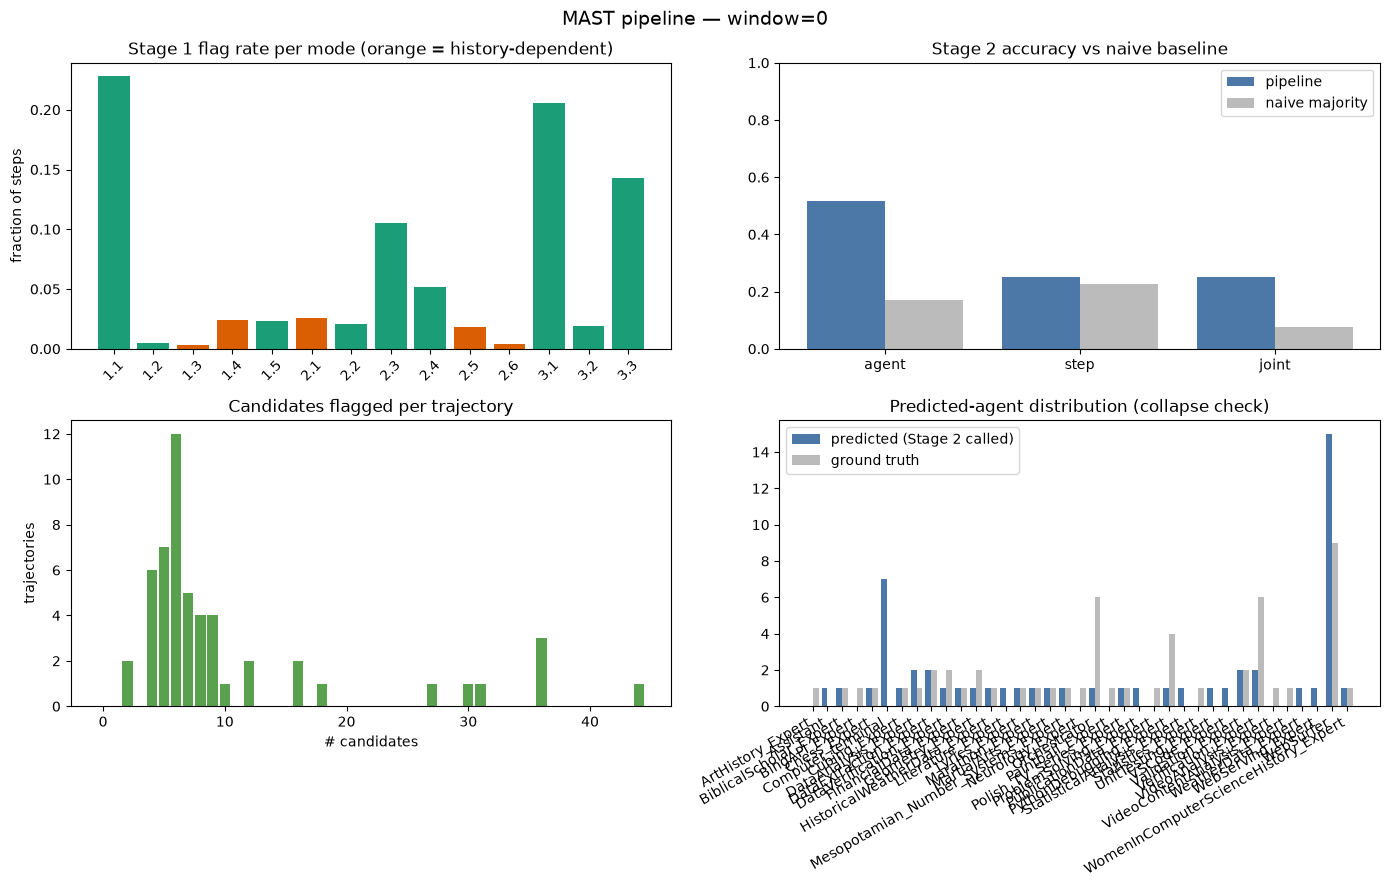

saved: window0_report.md | window0_plots.png


In [83]:
m0 = report_window(0)

### ⛔ Stop here — read the window=0 report first

Things to check before moving on: recall vs. flag rate (is it just flagging everything?), accuracy vs. the naive baseline, agent-correct/step-wrong share, prediction collapse, parse-error rate. Only then continue to Phase 3.

---
# Phase 3 — window = 3

Same as Phase 2, but Stage 1 also sees the last 3 step summaries. Refuses to run unless the window=0 report exists.

In [84]:
assert report_path(0).exists(), "Phase 2 (window=0) has not been run and reported yet — do that first."
run_window(3)

summarizer: 0it [00:00, ?it/s]
window=3: 100%|██████████| 56/56 [10:25<00:00, 11.16s/it]


[{'kind': 'stage1',
  'window': 3,
  'trajectory_id': '55f4258484c5b398956133128a50462a767da211f8f72aa5ac5bbffb9bcbba1a',
  'step_id': 1,
  'agent': 'Orchestrator',
  'modes': [],
  'evidence': '',
  'parse_error': False,
  'raw': None,
  'in_tok': 1418,
  'out_tok': 8,
  'latency': 2.2126271724700928,
  'attempts': 1},
 {'kind': 'stage1',
  'window': 3,
  'trajectory_id': '55f4258484c5b398956133128a50462a767da211f8f72aa5ac5bbffb9bcbba1a',
  'step_id': 2,
  'agent': 'Orchestrator',
  'modes': [],
  'evidence': '',
  'parse_error': False,
  'raw': None,
  'in_tok': 1114,
  'out_tok': 8,
  'latency': 1.8290061950683594,
  'attempts': 1},
 {'kind': 'stage1',
  'window': 3,
  'trajectory_id': '55f4258484c5b398956133128a50462a767da211f8f72aa5ac5bbffb9bcbba1a',
  'step_id': 3,
  'agent': 'Orchestrator',
  'modes': ['1.1', '2.1', '3.1'],
  'evidence': '"Please search for a list of series that Ted Danson has starred in, and confirm which of those series have more than one season. Additionally,

summarizer: 0it [00:00, ?it/s]
summarizer: 0it [00:00, ?it/s]


# MAST pipeline — window=3 report

56 trajectories, 1334 steps. Model: mlx-community/Qwen3-8B-4bit (4bit=True).

## Headline

- **Recall of true mistake steps (flagged by Stage 1):** 88.7% of 53 (via history-dependent modes: 18.9%; via context-independent modes: 86.8%)
- Overall step flag rate: 69.9%  |  zero-candidate trajectories: 0.0%  |  Stage 2 UNSURE rate: 0.0%
- **Agent / step / joint accuracy:** 51.8% / 25.0% / 25.0%
- Naive majority baseline: agent 17.0% (always 'WebSurfer'), step 22.6% (always 1), joint 7.5% (always ('PythonDebugging_Expert', 0))
- Agent-correct / step-wrong: 15 trajectories (51.7% of agent-correct predictions)
- Predicted-agent distribution: {'WebSurfer': 12, 'Orchestrator': 3, 'BingAPI_Expert': 1, 'ProblemSolving_Expert': 1, 'Assistant': 1, 'Computer_terminal': 6, 'Lyrics_Expert': 1, 'PythonDebugging_Expert': 3, 'WomenInComputerScienceHistory_Expert': 1, 'Cubing_Expert': 1, 'Polish_TV_Series_Expert': 1, 'NumericalMethods_Expert': 1, 'PublicationData_Expert': 1, 'Mesopotamian_Number_Systems_Expert': 1, 'Geometry_Expert': 1, 'DataExtraction_Expert': 2, 'BiblicalScholar_Expert': 1, 'WebServing_Expert': 1, 'VideoAnalysis_Expert': 1, 'Literature_Expert': 1, 'DataVerification_Expert': 1, 'CelestialPhysics_Expert': 1, 'StatisticalAnalysis_Expert': 1, 'Chess_Expert': 1, 'FinancialData_Expert': 1, 'Validation_Expert': 1, 'Bioinformatics_Expert': 1, 'HistoricalWeatherData_Expert': 1, 'Verification_Expert': 1, 'WeatherData_Expert': 1, 'Karting_Expert': 1, 'NYC_Local_Expert': 1}  (ground truth: {'WebSurfer': 9, 'Orchestrator': 6, 'BingAPI_Expert': 1, 'Geometry_Expert': 2, 'Verification_Expert': 6, 'Validation_Expert': 2, 'ArtHistory_Expert': 1, 'Lyrics_Expert': 1, 'PythonDebugging_Expert': 4, 'WomenInComputerScienceHistory_Expert': 1, 'Cubing_Expert': 1, 'Polish_TV_Series_Expert': 1, 'PublicationData_Expert': 1, 'Mesopotamian_Number_Systems_Expert': 1, 'DataExtraction_Expert': 2, 'VideoContentAnalysis_Expert': 1, 'BiblicalScholar_Expert': 1, 'VideoAnalysis_Expert': 1, 'Neurology_Expert': 1, 'DataVerification_Expert': 2, 'Marathon_Expert': 1, 'DataAnalysis_Expert': 1, 'Chess_Expert': 1, 'FinancialData_Expert': 1, 'HistoricalWeatherData_Expert': 1, 'Statistics_Expert': 1, 'Paintball_Expert': 1, 'MartialArts_Expert': 1})
- parse_error rates — Summarizer 0.00%, Stage 1 0.00%, Stage 2 0.00%; parse errors on ground-truth steps: 0
- Cost: 49368 tokens/trajectory (2764621 total; Stage 1 avg input 1166 tokens/step), 148.5s/trajectory

## Mode flag counts

|     |   count | rate   | history_dependent   |
|----:|--------:|:-------|:--------------------|
| 1.1 |     326 | 24.44% | False               |
| 1.2 |       8 | 0.60%  | False               |
| 1.3 |      18 | 1.35%  | True                |
| 1.4 |      53 | 3.97%  | True                |
| 1.5 |       6 | 0.45%  | False               |
| 2.1 |     255 | 19.12% | True                |
| 2.2 |      68 | 5.10%  | False               |
| 2.3 |     136 | 10.19% | False               |
| 2.4 |      79 | 5.92%  | False               |
| 2.5 |     134 | 10.04% | True                |
| 2.6 |       6 | 0.45%  | True                |
| 3.1 |     331 | 24.81% | False               |
| 3.2 |      65 | 4.87%  | False               |
| 3.3 |     209 | 15.67% | False               |

## Comparison against earlier windows

|                        |             0 |             3 |
|:-----------------------|--------------:|--------------:|
| recall                 |     0.716981  |     0.886792  |
| recall_hist_modes      |     0.113208  |     0.188679  |
| recall_ctx_indep_modes |     0.698113  |     0.867925  |
| step_flag_rate         |     0.421289  |     0.698651  |
| agent_acc              |     0.517857  |     0.517857  |
| step_acc               |     0.25      |     0.25      |
| joint_acc              |     0.25      |     0.25      |
| naive_agent            |     0.169811  |     0.169811  |
| naive_step             |     0.226415  |     0.226415  |
| naive_joint            |     0.0754717 |     0.0754717 |
| zero_cand_rate         |     0         |     0         |
| unsure_rate            |     0         |     0         |
| parse_err_s1           |     0         |     0         |
| tokens/traj            | 45865         | 49368         |
| stage1_in_tok/step     |  1065         |  1166         |
| latency/traj_s         |   130.2       |   148.5       |

### Mode flag rate by window

|     |    w=0 |    w=3 |
|----:|-------:|-------:|
| 1.1 | 0.2279 | 0.2444 |
| 1.2 | 0.0045 | 0.006  |
| 1.3 | 0.003  | 0.0135 |
| 1.4 | 0.024  | 0.0397 |
| 1.5 | 0.0232 | 0.0045 |
| 2.1 | 0.0255 | 0.1912 |
| 2.2 | 0.021  | 0.051  |
| 2.3 | 0.1049 | 0.1019 |
| 2.4 | 0.0517 | 0.0592 |
| 2.5 | 0.018  | 0.1004 |
| 2.6 | 0.0037 | 0.0045 |
| 3.1 | 0.2054 | 0.2481 |
| 3.2 | 0.0187 | 0.0487 |
| 3.3 | 0.1432 | 0.1567 |

## Skepticism checklist

- Compare each accuracy to the naive baseline above (a number near the baseline is not a result).
- Agent-correct/step-wrong share: a high share means agent accuracy is partly hollow.
- Predicted-agent distribution vs ground truth: one agent dominating = prediction-space collapse.
- Context-independent modes should be roughly flat across windows; large swings deserve investigation.

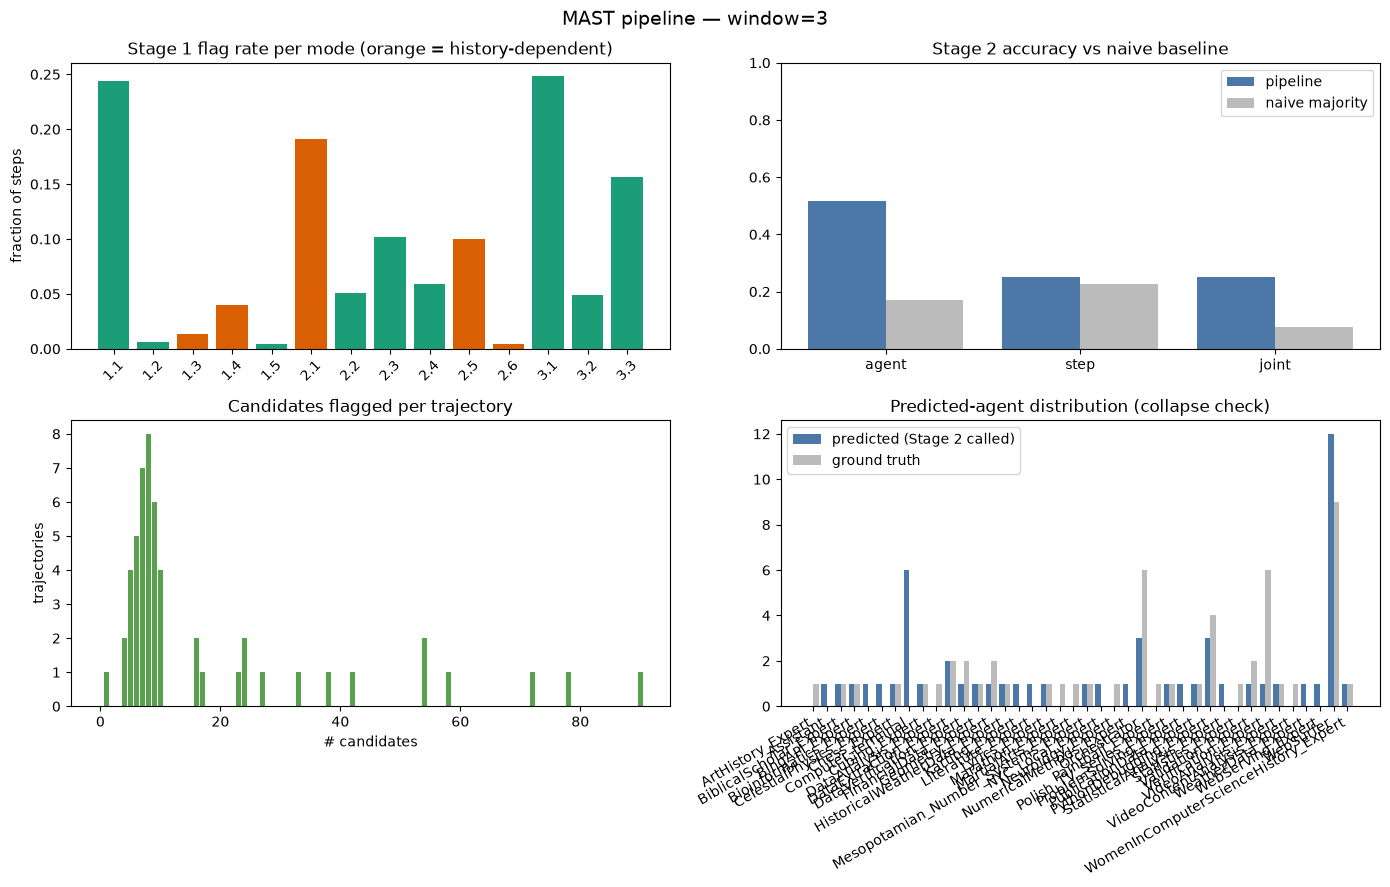

saved: window3_report.md | window3_plots.png


In [85]:
m3 = report_window(3, prior_windows=[0])

### ⛔ Stop here — read the window=3 report and the comparison vs window=0

The plan's early-stop rule: if window=3 already saturates recall on the history-dependent modes, window=all may not be worth running — say so if the data shows it.

---
# Phase 4 — window = all

Stage 1 sees every prior step summary. Refuses to run unless the window=3 report exists.

In [ ]:
assert report_path(3).exists(), "Phase 3 (window=3) has not been run and reported yet — do that first."
run_window("all")

In [ ]:
mAll = report_window("all", prior_windows=[0, 3])

---
# Combined comparison (only after all three windows are done and reported)

In [ ]:
assert all(report_path(w).exists() for w in (0, 3, "all")), "Run and report all three windows first."
ms = [compute_metrics(w) for w in (0, 3, "all")]
names = ["window=0", "window=3", "window=all"]

# 1) Recall of true mistake steps, split by history-dependent vs context-independent modes
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
x = range(3)
ax[0].bar([i - 0.2 for i in x], [m["recall_history_modes"] for m in ms], 0.4, label="history-dependent modes", color="#d95f02")
ax[0].bar([i + 0.2 for i in x], [m["recall_context_indep_modes"] for m in ms], 0.4, label="context-independent modes", color="#1b9e77")
ax[0].plot(list(x), [m["recall"] for m in ms], "k o-", label="any mode (overall recall)")
ax[0].set_xticks(list(x)); ax[0].set_xticklabels(names); ax[0].set_ylim(0, 1); ax[0].legend(fontsize=8)
ax[0].set_title("Recall of true mistake steps")
# 2) cost
ax[1].bar(names, [m["tokens_per_traj"] for m in ms], color="#4c78a8"); ax[1].set_title("Tokens per trajectory (Summarizer+S1+S2)")
for i, m in enumerate(ms): ax[1].text(i, m["tokens_per_traj"], f'{m["tokens_per_traj"]:.0f}', ha="center", va="bottom")
# 3) per-mode flag rate across windows
import numpy as np
xx = np.arange(len(ALL_MODES))
for i, m in enumerate(ms): ax[2].bar(xx + (i - 1) * 0.27, [m["mode_flag_rate"][c] for c in ALL_MODES], 0.27, label=names[i])
ax[2].set_xticks(xx); ax[2].set_xticklabels(ALL_MODES, rotation=45); ax[2].legend(); ax[2].set_title("Mode flag rate by window")
plt.tight_layout(); fig.savefig(OUT_DIR / f"combined_comparison{SUFFIX}.png", dpi=130); plt.show()

# 3) headline table
table = pd.DataFrame([headline_row(m) for m in ms]).set_index("window")
(OUT_DIR / f"combined_headline_table{SUFFIX}.md").write_text(table.T.to_markdown())
table.T

---
# Investigation — spurious pattern-matching in 2.1, and the Computer_terminal Stage 2 picks

Ad hoc checks against a specific window's results (defaults to window=3, edit `INVESTIGATE_WINDOW` below). These don't feed into the metrics/report cells above -- they're for reading raw evidence against raw step text to sanity-check what Stage 1 / Stage 2 are actually doing.

In [41]:
INVESTIGATE_WINDOW = 3   # which results_window*.jsonl to inspect

# Ground truth for step_id -> raw (agent, text) may live across more than one held-out file if
# HELD_OUT_PATH was changed between runs. Load every held_out_test_set.json this project knows
# about and index by question_ID, so a trajectory_id resolves regardless of which file it came from.
_ALL_HELD_OUT_FILES = [HELD_OUT_PATH] + [p for p in HELD_OUT_CANDIDATES if p != HELD_OUT_PATH and p.exists()]
_extra = [PROJECT_DIR.parent / "Experiment3" / "whodunit_experiment3_v2" / "held_out_test_set.json",
          PROJECT_DIR.parent / "Experiment3" / "whodunit_experiment3" / "held_out_test_set.json"]
for p in _extra:
    if p.exists() and p not in _ALL_HELD_OUT_FILES: _ALL_HELD_OUT_FILES.append(p)

_raw_steps_by_traj = {}
for p in _ALL_HELD_OUT_FILES:
    for t in json.loads(p.read_text()):
        qid = t["question_ID"]
        if qid in _raw_steps_by_traj: continue
        steps = {}
        for i, item in enumerate(t.get("history", [])):
            agent = base_role(item.get("name") or item.get("role", ""))
            if agent.lower() == "human": continue
            c = item.get("content", "")
            steps[i] = (agent, c if isinstance(c, str) else json.dumps(c, ensure_ascii=False))
        _raw_steps_by_traj[qid] = steps
print(f"raw step text indexed for {len(_raw_steps_by_traj)} trajectories, from {[p.name for p in _ALL_HELD_OUT_FILES if p.exists()]}")

def raw_step(tid, step_id):
    return _raw_steps_by_traj.get(tid, {}).get(step_id, ("<unknown agent>", "<step text not found -- trajectory_id not in any held_out_test_set.json this notebook knows about>"))

raw step text indexed for 53 trajectories, from ['held_out_test_set.json', 'held_out_test_set.json']


## 2.1 (Conversation Reset) -- evidence quotes vs. the real step text

Pulls a random sample of every step Stage 1 flagged with 2.1 in the chosen window, and prints the model's evidence quote next to the actual step text it was judging. Read for whether the quote is really evidence of a reset, or whether the model is pattern-matching on routing boilerplate ("Next speaker X") or on Orchestrator planning text that merely *mentions* redirecting an agent.

In [42]:
import random

_recs = read_jsonl(results_path(INVESTIGATE_WINDOW))
_s1 = [r for r in _recs if r["kind"] == "stage1"]
_mode21 = [r for r in _s1 if "2.1" in r["modes"]]
print(f"window={INVESTIGATE_WINDOW}: {len(_mode21)} / {len(_s1)} steps flagged 2.1 ({len(_mode21) / max(1, len(_s1)):.1%} of all steps)")

# How many of the 2.1 evidence quotes are (near-)exactly "Next speaker <Agent>" -- i.e. Orchestrator
# turn-taking boilerplate with no reset-relevant content at all.
_next_speaker_re = re.compile(r'"?next speaker \w+"?\.?')
_boilerplate = sum(bool(_next_speaker_re.fullmatch(r["evidence"].strip().lower())) for r in _mode21)
print(f"  of which {_boilerplate} ({_boilerplate / max(1, len(_mode21)):.1%}) are bare 'Next speaker X' routing lines")

random.seed(0)
_sample = random.sample(_mode21, min(10, len(_mode21)))
for r in _sample:
    tid, sid = r["trajectory_id"], r["step_id"]
    agent, text = raw_step(tid, sid)
    print("\n--- traj", tid[:12], "step", sid, "| agent=", r["agent"], "| modes=", r["modes"])
    print("EVIDENCE :", r["evidence"][:300])
    print("RAW STEP :", " ".join(text.split())[:350])

window=3: 369 / 1708 steps flagged 2.1 (21.6% of all steps)
  of which 125 (33.9%) are bare 'Next speaker X' routing lines

--- traj 55f4258484c5 step 36 | agent= Orchestrator | modes= ['1.4', '2.1']
EVIDENCE : "We have been repeating similar actions of scrolling and looking for information without making significant progress towards identifying all TV series featuring Ted Danson with more than 1 season." (1.4 Loss of Conversation History), "WebSurfer needs to be redirected to access the comprehensive IMDb
RAW STEP : Updated Ledger: { "is_request_satisfied": { "reason": "The request has not yet been fully satisfied as we have not identified the worst-rated series with more than 1 season that Ted Danson has starred in and is available on Amazon Prime Video (US).", "answer": false }, "is_in_loop": { "reason": "We have been repeating similar actions of scrolling a

--- traj 0a65cb96-cb6 step 23 | agent= Orchestrator | modes= ['2.1']
EVIDENCE : "Next speaker WebSurfer"
RAW STEP : Next spea

## Computer_terminal Stage 2 picks -- terminal's own action, or an earlier expert's?

For every trajectory where Stage 2 named `Computer_terminal` as the decisive agent, this prints: Stage 2's justification, the terminal's own step text (almost always a traceback/exitcode), every other candidate Stage 1 flagged in that trajectory, and the steps immediately before the picked step.

**What to look for:** if an earlier step (typically the expert who wrote the buggy code) was *also* flagged as a candidate and Stage 2 still picked the terminal echoing the error, that's a Stage 2 counterfactual-reasoning failure -- no window size fixes it, since Stage 1 already surfaced the right candidate. If the code-authoring step was never flagged as a candidate at all, that's a Stage 1 recall gap instead.

In [43]:
_s2 = [r for r in _recs if r["kind"] == "stage2"]
_ct_preds = [r for r in _s2 if r["predicted_agent"] == "Computer_terminal"]
print(f"window={INVESTIGATE_WINDOW}: {len(_ct_preds)} / {len(_s2)} trajectories predicted Computer_terminal as the decisive agent")

_earlier_candidate_available = 0
for r in _ct_preds:
    tid, ps = r["trajectory_id"], r["predicted_step"]
    cands = sorted([x for x in _s1 if x["trajectory_id"] == tid and x["modes"]], key=lambda x: x["step_id"])
    earlier_non_terminal = [c for c in cands if c["step_id"] < ps and c["agent"] != "Computer_terminal"]
    _earlier_candidate_available += bool(earlier_non_terminal)
    agent, text = raw_step(tid, ps)
    print(f"\n=== traj {tid[:12]} predicted_step={ps} (predicted agent: Computer_terminal) ===")
    print("JUSTIFICATION:", r["justification"][:250])
    print("TERMINAL'S OWN STEP TEXT:", " ".join(text.split())[:220])
    print("ALL FLAGGED CANDIDATES:", [(c["step_id"], c["agent"], c["modes"]) for c in cands])
    if earlier_non_terminal:
        print("  -> an EARLIER non-terminal candidate existed and was passed over:",
              [(c["step_id"], c["agent"], c["modes"]) for c in earlier_non_terminal])
    else:
        print("  -> no earlier non-terminal candidate was flagged; Stage 1 may have missed the real authoring step")
    for pid in sorted(i for i in _raw_steps_by_traj.get(tid, {}) if i < ps)[-3:]:
        pa, pt = _raw_steps_by_traj[tid][pid]
        print("   prior step", pid, f"({pa}):", " ".join(pt.split())[:150])

print(f"\n\nSummary: {_earlier_candidate_available}/{len(_ct_preds)} Computer_terminal picks had an earlier, "
      f"already-flagged non-terminal candidate available -- i.e. this many are Stage 2 counterfactual-reasoning "
      f"misses rather than Stage 1 recall gaps.")

window=3: 13 / 61 trajectories predicted Computer_terminal as the decisive agent

=== traj 08f3a05f-594 predicted_step=2 (predicted agent: Computer_terminal) ===
JUSTIFICATION: If step 2 had properly defined variables and shared necessary information, the subsequent steps would have addressed the NameError, preventing the failure in the verification process.
TERMINAL'S OWN STEP TEXT: exitcode: 1 (execution failed) Code output: Traceback (most recent call last): File "/home/CaptainAgent/groupchat/tmp_code_6ce8da89896a7862a1307ed7c5251cd4.py", line 22, in <module> f = sp.Lambda(x, x**3 + 4*x**2 - 3*x +
ALL FLAGGED CANDIDATES: [(0, 'NumericalMethods_Expert', ['1.1', '1.2', '2.5', '3.3']), (2, 'Computer_terminal', ['1.1', '2.4']), (3, 'Verification_Expert', ['2.5']), (4, 'Computer_terminal', ['3.1', '3.3']), (5, 'Verification_Expert', ['3.3']), (7, 'NumericalMethods_Expert', ['3.1', '3.3']), (8, 'NumericalMethods_Expert', ['1.5'])]
  -> an EARLIER non-terminal candidate existed and was pas

## Summarizer spot-check -- raw step text vs. the one-line summary

Three random (trajectory, step) pairs: the full raw step text the Summarizer saw, and the summary it produced. Read for drift (does the summary state something not in the raw text?), evaluative language slipping in despite the prompt's ban on it, and information loss that would make Stage 1's windowed prefix misleading.

In [44]:
_summaries = get_summaries()
_all_step_keys = [(t["trajectory_id"], s["step_id"]) for t in trajectories for s in t["steps"]]
random.seed(1)
for tid, sid in random.sample(_all_step_keys, 3):
    agent, text = raw_step(tid, sid)
    rec = _summaries.get((tid, sid))
    print("\n=== traj", tid[:12], "step", sid, "| agent=", agent, "===")
    print("RAW STEP TEXT:")
    print("  " + " ".join(text.split())[:600])
    print("SUMMARY:", rec["summary"] if rec and not rec["parse_error"] else f"<parse_error: {rec}>")

summarizer: 0it [00:00, ?it/s]


=== traj 624cbf11-6a4 step 83 | agent= Orchestrator ===
RAW STEP TEXT:
  Please visit the official Ben & Jerry's Flavor Graveyard page directly at [Ben & Jerry's Flavor Graveyard](https://www.benjerry.com/flavors/flavor-graveyard) and search for the oldest flavor's headstone by reviewing the flavors in the order they were added. Once identified, examine the photo of the headstone and identify any visible headstones in the background to retrieve the last line of the rhyme under the flavor name.
SUMMARY: The Orchestrator visited Ben & Jerry's Flavor Graveyard website, searched for the oldest flavor's headstone by reviewing flavors in addition order, examined the headstone photo, and identified visible background headstones to retrieve the last line of the rhyme.

=== traj ecbc4f94-95a step 9 | agent= DataVerification_Expert ===
RAW STEP TEXT:
  TERMINATE
SUMMARY: DataVerification_Expert terminated the process.

=== traj 0a65cb96-cb6 step 45 | agent= Orchestrator ===
RAW STEP TEXT:
  Ple